# Data Overview

End-to-end account of how the training data for this study is sourced, cropped,
labelled and split, and of every decision made to keep a classifier from solving
the task without looking at morphology.

Read this before `training.ipynb`. The order below is the order the pipeline
runs in.

| # | Stage | Code |
|---|---|---|
| 1 | Sources: MGC^3 catalogue and DeepLandforms tiles | -- |
| 2 | What the raw tiles leak, and why they cannot be used as they are | -- |
| 3 | Crop policy: side, offset, augmentation | `data/optical/landform_crops.py` |
| 4 | Annotation table, one row per landform | `landform_crops.annotation_table` |
| 5 | Splitting: three leakage relations, two grouping levels | `model/hirise_dataset.py` |
| 6 | What the data set actually contains | -- |
| 7 | Thermal coverage, and why its gaps are not random | `model/baselines.py` |
| 8 | The superseded negative class, and what it cost | -- |

The thermal side lives in `data/thermal/thermal_data_collection.ipynb`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Every path here is relative to the repository root, which is where this
# notebook lives.
DATA = "data"
TILE_DIR = os.path.join(DATA, "optical", "DeepLandforms_dataset")
DATASET_JSON = os.path.join(TILE_DIR, "dataset.json")
CAVE_CATALOG = os.path.join(DATA, "Mars_Extended_Cave_Catalog.csv")
FINAL_DIR = os.path.join(DATA, "optical", "final_data")
ANNOTATIONS = os.path.join(FINAL_DIR, "annotations.json")

os.makedirs(FINAL_DIR, exist_ok=True)

for label, path in [("tiles", TILE_DIR), ("dataset.json", DATASET_JSON),
                    ("cave catalogue", CAVE_CATALOG)]:
    print(f"{'OK     ' if os.path.exists(path) else 'MISSING'} {label:15s} {path}")

OK      tiles           data\optical\DeepLandforms_dataset
OK      dataset.json    data\optical\DeepLandforms_dataset\dataset.json
OK      cave catalogue  data\Mars_Extended_Cave_Catalog.csv


## 1. Sources

### 1.1 Mars Global Cave Candidate Catalog (MGC^3)

G. E. Cushing (2015), *Mars Global Cave Candidate Catalog PDS4 Archive Bundle*,
PDS Cartography and Imaging Sciences Node, https://doi.org/10.17189/1519222

Used for context and for cross-checking positions, not as a label source.
Elevations were attached with [pygmt](https://www.pygmt.org/).

In [2]:
cave_catalog = pd.read_csv(CAVE_CATALOG)
print(f"{len(cave_catalog)} catalogue entries")
print(cave_catalog["TypeCode"].value_counts().head(8).to_string())

diameters = pd.to_numeric(cave_catalog["APC_Diameter"], errors="coerce").dropna()
print(f"\nAPC diameter, n={len(diameters)}: median {diameters.median():.0f} m, "
      f"{(diameters >= 100).mean() * 100:.0f}% at or above 100 m")
cave_catalog.head()

1062 catalogue entries
TypeCode
sky    354
srp    218
APC    132
crk     87
pin     60
flr     42
pit     37
irr     36

APC diameter, n=131: median 120 m, 66% at or above 100 m


,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation
0,APC001,240.4585,-0.94678,APC,1,25,32.0,APC -- tiny ~25m,5845.516289
1,APC003,237.6960,-12.47266,APC,1,30,47.0,APC 40m small deep nochain--big smrp?,10500.439389
2,APC005,240.8867,-5.68445,APC,1,30,17.0,APC deep pair,10144.570834
3,APC006,240.9421,-1.61377,APC,1,40,38.0,APC small deep?,6446.123804
4,APC007,241.2993,-1.68555,APC,1,40,28.0,"APC, deep? ~40m",6610.563531


### 1.2 DeepLandforms

Nodjoumi, Pozzobon, Sauro & Rossi (2023), *DeepLandforms: A Deep Learning
computer vision toolset applied to a prime use case for mapping planetary
skylights*, Earth and Space Science 10, e2022EA002278.
Data: https://zenodo.org/records/6818611

One GeoTIFF tile per annotated landform, cut from HiRISE RED products and
downscaled to 0.5, 1, 2, 3 and 5 m/pixel, each with a LabelMe polygon.

**Classes.** `dataset.json` names them `Type-1`, `Type-2`, `Type-4`; the
definitions live in Figure 3 of the paper, which is an image, so they are
transcribed here. The mapping below was *verified* against the per-tile LabelMe
JSONs rather than inferred: 615 `Type-1`, 657 `Type-4` and 559 `Type-2` agree
with `category_id` 0, 1 and 2 respectively, with no disagreement.

| id | Nodjoumi | Definition (Fig. 3) | Name used here |
|---|---|---|---|
| 0 | Type-1 | Skylight with possible cave entrance. Quasi-circular, flat rim, no ejecta, **almost nonvisible bottom**, vertical to overhanging walls (1a); sub-vertical walls with visible bottom (1b). | Vertical Pit / Skylight |
| 1 | Type-4 | Possible connection to lava tubes **through alignment of multiple similar shapes**. Semicircular, flat rim, no ejecta, **shallow to very shallow**, visible flat bottom. | Aligned Shallow Pit |
| 2 | Type-2 | "Bowl" or semi-elliptic pit, **uncertain** connection to lava tubes. Flat rim, no ejecta, **sloped walls, visible convex bottom**. | Sloped Pit |

Type-3 (coalescent pits) and the Crater class exist in the full DeepLandforms
labelling but not in this released subset.

**On the Type-4 name.** It is tempting to read Type-4 as "pit chain", but the
annotation covers a *single* pit, never a chain. Measured over all 1846
annotations: every one carries exactly one polygon, the median bbox aspect ratio
is 1.10, and the polygon fills 0.757 of its bbox -- a circle inscribed in a
square fills 0.785. Type-4 is one round pit that happens to be *aligned with*
others, so it is named "Aligned Shallow Pit" here.

That distinction matters for more than naming. The evidence that makes a pit
Type-4 rather than Type-2 -- the alignment -- lies **outside** the annotated
footprint, and often outside the tile: the class is assigned from context the
crop does not contain, and sometimes that the tile does not contain either. It
is the most likely explanation for the Type-4 / Type-2 confusion measured in
`training.ipynb`, where the two account for 339 of 524 baseline errors while
Type-1 separates cleanly.

**Why this is the task.** Type-1 is the skylight class by definition, so
"Type-1 versus the rest" is the discrimination that matters for cave detection.
It is also the one Cushing et al. (2007) built the thermal test for: a skylight
shows a *smaller diurnal temperature amplitude than the collapse pits next to
it*. And it is exactly where optical morphology struggles -- Nodjoumi records
that Type-1b, Type-2a and Type-4 look alike at low solar incidence angle, and
recommends topographic profiles or context analysis to separate them. That is
the argument for a second modality, stated by the source of the labels.

In [3]:
with open(DATASET_JSON) as handle:
    deep_landforms = json.load(handle)

tiles = pd.DataFrame(deep_landforms["images"])
labels = pd.DataFrame(deep_landforms["annotations"])
categories = pd.DataFrame(deep_landforms["categories"])

CLASS_NAMES = {0: "Vertical Pit/Skylight", 1: "Aligned Shallow Pit", 2: "Sloped Pit"}

print(f"{len(tiles)} tiles, {len(labels)} annotations")
print(categories.to_string(index=False))
print()
print(labels["category_id"].map(CLASS_NAMES).value_counts().to_string())
print("\ntiles carrying more than one annotation:",
      int((labels.groupby("image_id").size() > 1).sum()))

1836 tiles, 1846 annotations
 id   name supercategory
  0 Type-1        Type-1
  1 Type-4        Type-4
  2 Type-2        Type-2

category_id
Aligned Shallow Pit      657
Vertical Pit/Skylight    625
Sloped Pit               564

tiles carrying more than one annotation: 5


## 2. What the raw tiles leak

DeepLandforms cuts each tile *centred on* its landform and *sized in proportion
to* it. Both are shortcuts with nothing to do with morphology:

* **Position** -- the landform is always in the middle, so "is there a blob at
  the centre" is enough to find one.
* **Tile size** -- the tile side tracks the landform size, and landform size is
  strongly class-dependent, so the raster dimensions alone carry much of the
  label.

The cell below measures both. `bbox` is used as the landform footprint
throughout: it is exactly the tight bound of the segmentation polygon here
(total absolute disagreement 377 px over all 1846 annotations, i.e. rounding),
so parsing the polygons would add nothing.

In [4]:
sizes = labels.merge(tiles, left_on="image_id", right_on="id", suffixes=("", "_tile"))
sizes["resolution_mpp"] = (
    sizes["file_name"].str.extract(r"_resized_([0-9.]+)_").astype(float)
)
sizes["box_px"] = sizes["bbox"].apply(lambda b: max(float(b[2]), float(b[3])))
sizes["diameter_m"] = sizes["box_px"] * sizes["resolution_mpp"]
sizes["tile_m"] = sizes["width"] * sizes["resolution_mpp"]
sizes["class"] = sizes["category_id"].map(CLASS_NAMES)

print("Annotated diameter (m) -- absolute size is itself a strong class cue:")
print(sizes.groupby("class")["diameter_m"]
      .describe(percentiles=[.1, .5, .9])[["10%", "50%", "90%", "max"]]
      .round(0).to_string())

print("\nTile side / landform side -- how much room a crop has to move in:")
print((sizes["tile_m"] / sizes["diameter_m"])
      .describe(percentiles=[.05, .25, .5, .9]).round(2).to_string())
print("\nThe minimum is above 1, so every tile contains its own landform and")
print("no annotation has to be discarded for lack of room.")

Annotated diameter (m) -- absolute size is itself a strong class cue:
                         10%    50%     90%     max
class                                              
Aligned Shallow Pit    276.0  512.0   781.0  1512.0
Sloped Pit             256.0  779.0  1960.0  4175.0
Vertical Pit/Skylight   55.0  155.0   326.0   546.0

Tile side / landform side -- how much room a crop has to move in:
count    1846.00
mean        7.58
std         9.54
min         1.38
5%          1.88
25%         2.54
50%         3.93
90%        17.71
max        90.00

The minimum is above 1, so every tile contains its own landform and
no annotation has to be discarded for lack of room.


## 3. Crop policy

`data/optical/landform_crops.py`. One crop per annotation, from every tile:

* **Side** = `context` x the annotation's longest edge, clamped to the tile. The
  landform therefore fills a roughly constant fraction of every frame and the
  raster dimensions stop encoding the class. Absolute scale is not discarded --
  it moves out of the pixels and into `resolution_mpp` and `diameter_m` in the
  annotation table, so a model can be given it explicitly, or trained without it
  to show whether morphology alone carries the class.
* **Offset** = random, constrained so the whole annotation stays inside the crop
  and the crop stays inside the tile. Redrawn on **every access**, so a landform
  sits somewhere different each epoch. This is why crops are cut on the fly
  rather than baked to disk: a pre-cut directory freezes one offset per sample
  and throws the augmentation away.
* **Dihedral augmentation** = random flip and quarter turn, on top of the offset.
  Safe here because shadow fraction, rim sharpness and floor visibility are
  orientation-invariant; it would not be safe for anything reading slope
  direction.

### Choosing `context`

Not a free parameter. The crop is clamped to the tile, and the tile/landform
ratio is class-correlated, so a larger context factor runs out of tile more
often for some classes than others -- handing the positional cue straight back,
class-dependently. The cell below measures the trade-off. **1.75 is the largest
value at which the available jitter is flat across classes.**

In [5]:
from data.optical.landform_crops import _offset_range, plan_crop

def jitter_report(context):
    rows = []
    for row in sizes.itertuples():
        bx, by, bw, bh = (float(v) for v in row.bbox)
        longest = max(bw, bh)
        side = min(max(int(round(context * longest)), int(np.ceil(longest))),
                   row.width, row.height)
        col_lo, col_hi = _offset_range(bx, bw, side, row.width)
        row_lo, row_hi = _offset_range(by, bh, side, row.height)
        rows.append({
            "class": CLASS_NAMES[row.category_id],
            "jitter": min(col_hi - col_lo, row_hi - row_lo) / max(side, 1),
            "fill": longest / side,
        })
    return pd.DataFrame(rows).groupby("class").agg(
        median_jitter=("jitter", "median"),
        stuck_pct=("jitter", lambda s: round(100 * (s < 0.02).mean(), 1)),
        frame_filled=("fill", "median"),
    ).round(3)

for context in (1.75, 2.0, 2.5):
    print(f"--- context = {context} "
          f"(landform fills ~{100 / context:.0f}% of the frame) ---")
    print(jitter_report(context).to_string())
    print()
print("stuck_pct = share of annotations left with under 2% of the crop side to")
print("move in. At 2.5 it is 17/24/36% by class, and median jitter collapses")
print("for Sloped Pit -- the positional cue would be back, and class-dependent.")

--- context = 1.75 (landform fills ~57% of the frame) ---
                       median_jitter  stuck_pct  frame_filled
class                                                        
Aligned Shallow Pit            0.428        2.4         0.571
Sloped Pit                     0.428        7.4         0.571
Vertical Pit/Skylight          0.429        1.0         0.571

--- context = 2.0 (landform fills ~50% of the frame) ---
                       median_jitter  stuck_pct  frame_filled
class                                                        
Aligned Shallow Pit            0.500       13.9           0.5
Sloped Pit                     0.384       19.7           0.5
Vertical Pit/Skylight          0.500        2.7           0.5

--- context = 2.5 (landform fills ~40% of the frame) ---
                       median_jitter  stuck_pct  frame_filled
class                                                        
Aligned Shallow Pit            0.455       24.4           0.4
Sloped Pit          

### From tile to model input

Where a crop actually comes from.

1. The whole DeepLandforms tile as delivered, annotation in red, one planned crop
   window in cyan. Note that the annotation sits in the middle of the *tile* --
   that is the shortcut being removed.
2. The window cut out, at native resolution.
3. The same window resampled to `OUT_PX`, percentile-stretched and randomly
   turned: the tensor the network actually receives.

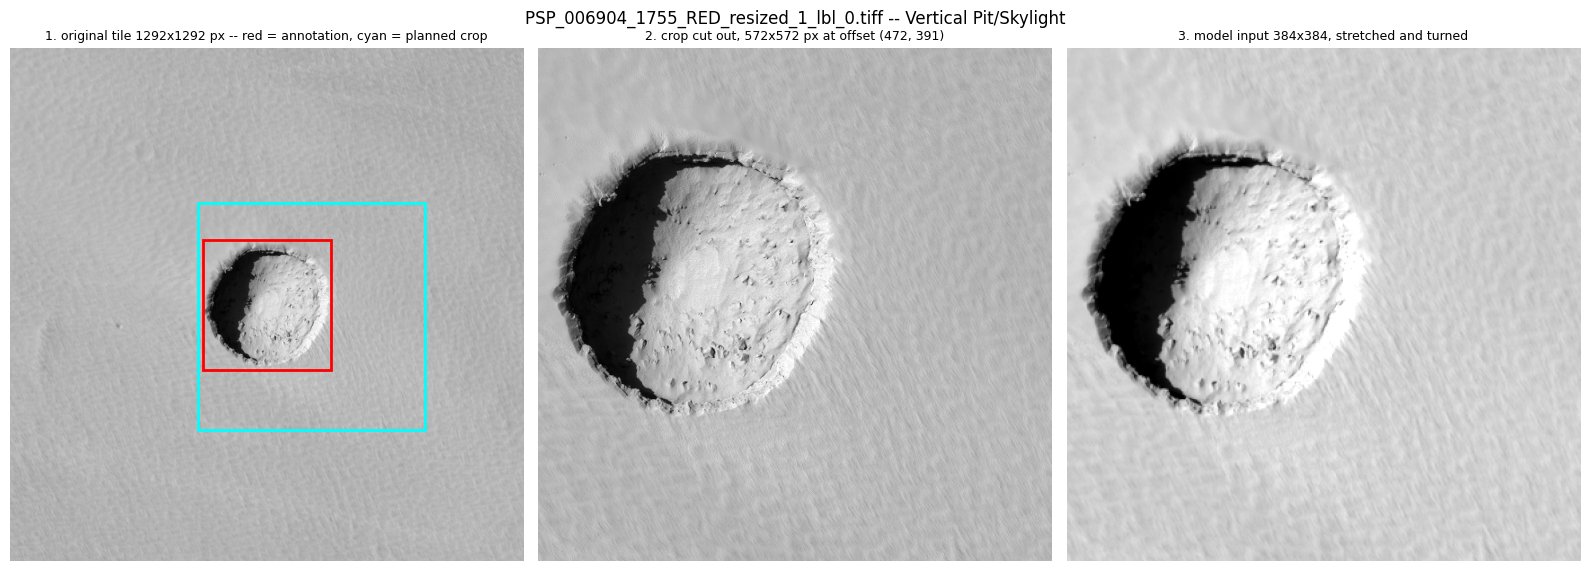

tile side / landform side = 4.0
crop covers 20% of the tile area


In [6]:
import matplotlib.patches as patches
import rasterio

from data.optical.landform_crops import plan_crop, read_crop
from model.hirise_dataset import LandformDataset

EXAMPLE = "PSP_006904_1755_RED_resized_1_lbl_0.tiff"
example = sizes[sizes.file_name == EXAMPLE].iloc[0]
example_path = os.path.join(TILE_DIR, EXAMPLE)

rng = np.random.default_rng(7)
plan = plan_crop(example["width"], example["height"], example["bbox"], 1.75, rng)

with rasterio.open(example_path) as src:
    whole_tile = src.read(1)

native = read_crop(example_path, plan)
model_input = LandformDataset.stretch_intensity(
    read_crop(example_path, plan, out_px=384)
)
model_input = LandformDataset.random_dihedral(model_input, rng)

bx, by, bw, bh = example["bbox"]

fig, axs = plt.subplots(1, 3, figsize=(16, 5.8))

axs[0].imshow(whole_tile, cmap="gray")
axs[0].add_patch(patches.Rectangle((bx, by), bw, bh, lw=2,
                                   edgecolor="red", facecolor="none"))
axs[0].add_patch(patches.Rectangle((plan.col_off, plan.row_off), plan.side,
                                   plan.side, lw=2, edgecolor="cyan",
                                   facecolor="none"))
axs[0].set_title(
    "1. original tile {}x{} px -- red = annotation, cyan = planned crop".format(
        example["width"], example["height"]), fontsize=9)

axs[1].imshow(native, cmap="gray")
axs[1].set_title(
    "2. crop cut out, {0}x{0} px at offset ({1}, {2})".format(
        plan.side, plan.col_off, plan.row_off), fontsize=9)

axs[2].imshow(model_input, cmap="gray")
axs[2].set_title("3. model input 384x384, stretched and turned", fontsize=9)

for ax in axs:
    ax.axis("off")
fig.suptitle("{} -- {}".format(EXAMPLE, CLASS_NAMES[example["category_id"]]))
plt.tight_layout()
plt.show()

longest = max(example["bbox"][2], example["bbox"][3])
print("tile side / landform side = {:.1f}".format(example["width"] / longest))
print("crop covers {:.0f}% of the tile area".format(
    100 * plan.side ** 2 / (example["width"] * example["height"])))

### What a crop looks like

Four independent draws of the same annotation. The landform stays whole and
inside the frame; where it sits, and its orientation, change every time.

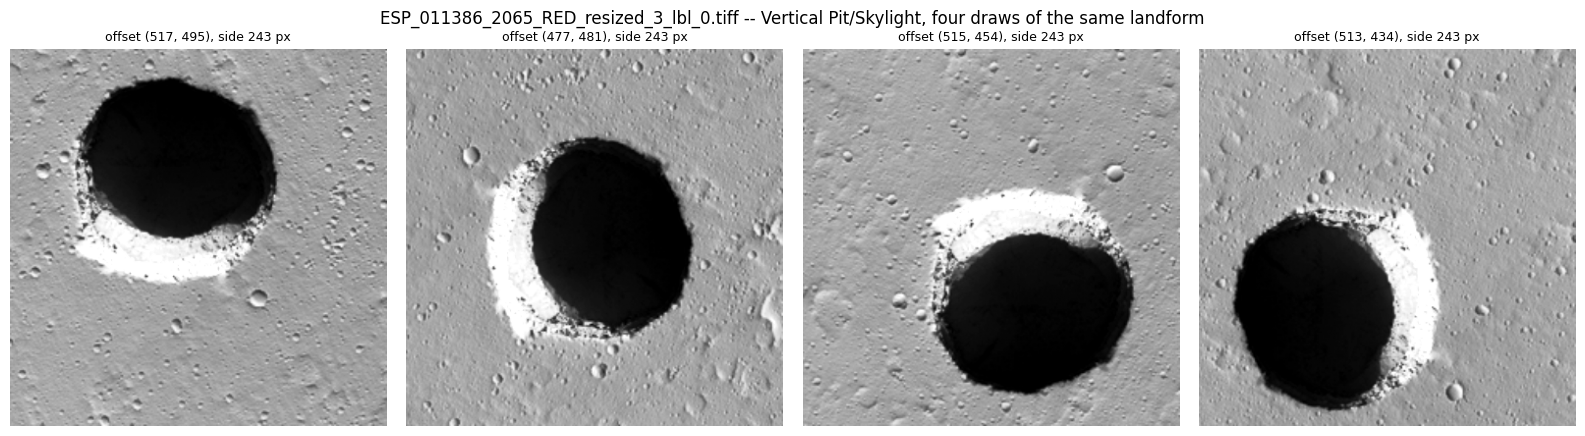

In [7]:
row = sizes[sizes.category_id == 0].iloc[3]
tile_path = os.path.join(TILE_DIR, row["file_name"])

fig, axs = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, seed in zip(axs, range(4)):
    rng = np.random.default_rng(seed)
    plan = plan_crop(row["width"], row["height"], row["bbox"], 1.75, rng)
    patch = LandformDataset.stretch_intensity(read_crop(tile_path, plan, out_px=384))
    patch = LandformDataset.random_dihedral(patch, rng)
    ax.imshow(patch, cmap="gray")
    ax.set_title(f"offset ({plan.col_off}, {plan.row_off}), side {plan.side} px",
                 fontsize=9)
    ax.axis("off")

fig.suptitle(f"{row['file_name']} -- {CLASS_NAMES[row['category_id']]}, "
             "four draws of the same landform")
plt.tight_layout()
plt.show()

## 4. Annotation table

One row per annotation, carrying everything the dataset and the split need.
Building it reads every tile's georeferencing, which takes about a minute, so
the result is cached to `data/optical/final_data/annotations.json`. Set
`REBUILD = True` to force a rebuild.

`lat` / `lon_east` are the centre of the **annotation**, not of the tile or of
the crop. The thermal pipeline keys its windows on that: a THEMIS pixel is
~100 m and the median annotated landform is 396 m across -- 155 m for Type-1 --
so a window centred on anything else misses the target.

In [8]:
from data.optical.landform_crops import annotation_table

REBUILD = not os.path.exists(ANNOTATIONS)

if REBUILD:
    annotations = annotation_table(DATASET_JSON, TILE_DIR, with_coordinates=True)
    annotations.to_json(ANNOTATIONS)
    print(f"\nwritten to {ANNOTATIONS}")
else:
    annotations = pd.read_json(ANNOTATIONS)
    print(f"loaded {len(annotations)} rows from {ANNOTATIONS}")

annotations.head()

loaded 1846 rows from data\optical\final_data\annotations.json


,image_name,img_path,category_id,category_name,bbox,landform_key,product,resolution_mpp,tile_width,tile_height,box_px,diameter_m,lat,lon_east
0,ESP_011386_2065_RED_resized_0.5_lbl_0.tiff,data/optical/DeepLandforms_dataset,0,Type-1,"[438, 449, 830, 799]",ESP_011386_2065_RED_lbl_0,ESP_011386_2065,0.5,1729,1728,830,415.0,26.148813,259.342976
1,ESP_011386_2065_RED_resized_0.5_lbl_1.tiff,data/optical/DeepLandforms_dataset,1,Type-4,"[523, 535, 1048, 1016]",ESP_011386_2065_RED_lbl_1,ESP_011386_2065,0.5,2116,2116,1048,524.0,26.124252,259.347467
2,ESP_011386_2065_RED_resized_1_lbl_0.tiff,data/optical/DeepLandforms_dataset,0,Type-1,"[399, 407, 415, 399]",ESP_011386_2065_RED_lbl_0,ESP_011386_2065,1.0,1212,1212,415,415.0,26.148813,259.342971
3,ESP_011386_2065_RED_resized_1_lbl_1.tiff,data/optical/DeepLandforms_dataset,1,Type-4,"[508, 516, 524, 508]",ESP_011386_2065_RED_lbl_1,ESP_011386_2065,1.0,1540,1540,524,524.0,26.124248,259.347472
4,ESP_011386_2065_RED_resized_2_lbl_0.tiff,data/optical/DeepLandforms_dataset,0,Type-1,"[400, 404, 208, 200]",ESP_011386_2065_RED_lbl_0,ESP_011386_2065,2.0,1008,1008,208,416.0,26.148813,259.342979


## 5. Splitting

`LandformDataset.group_keys`. Three separate things put correlated samples in
this data set, and a split that ignores any of them reports a score that is too
high:

1. **Resolution replicas** -- the same landform at 0.5/1/2/3/5 m/pixel. A random
   row split puts rescaled copies of one pit on both sides (measured on the
   earlier data set: 73.8% of validation images had a copy in training). Caught
   by stripping the resolution token from the filename.
2. **Repeat observations** -- the same pit imaged on several orbits under
   different product ids, so filenames give no hint they are the same feature.
   Caught by proximity on the ground, 300 m.
3. **Shared acquisition** -- two *different* landforms in one HiRISE product
   share season, solar incidence angle, calibration and local terrain. Caught by
   grouping on the product id.

Relations are combined by union-find, so a group is a connected component rather
than an intersection. Two levels are offered:

* `level="landform"` -- relations 1 and 2. Answers *can the model recognise a pit
  it has never seen?*
* `level="product"` -- all three. Answers *can it do that in an image it has
  never seen?* **This is the number to report.** The gap between the two
  measures how much the model leans on acquisition context.

Report both, and report *groups* as the sample size, never images.

In [9]:
dataset = LandformDataset(annotations, root_dir=".")

summary = []
for level in ("landform", "product"):
    groups = pd.Series(dataset.group_keys(level=level))
    per_class = pd.crosstab(groups, annotations["category_id"])
    summary.append({
        "level": level,
        "groups": groups.nunique(),
        "images": len(groups),
        "median group size": int(groups.value_counts().median()),
        "largest group, % of data": round(
            100 * groups.value_counts().iloc[0] / len(groups), 1),
        **{f"groups with {CLASS_NAMES[c]}": int((per_class[c] > 0).sum())
           for c in per_class.columns},
    })

print(pd.DataFrame(summary).set_index("level").T.to_string())
print("\n1846 images is NOT the sample size. 318 landform groups and 127")
print("product groups are.")

level                              landform  product
groups                                318.0    127.0
images                               1846.0   1846.0
median group size                       5.0     10.0
largest group, % of data                1.1      8.2
groups with Vertical Pit/Skylight      93.0     81.0
groups with Aligned Shallow Pit       111.0     37.0
groups with Sloped Pit                123.0     56.0

1846 images is NOT the sample size. 318 landform groups and 127
product groups are.


In [10]:
from model.training_utils import group_kfold_indices

# The folds have to hold: no group may appear on both sides of a split.
for level in ("landform", "product"):
    groups = np.array(dataset.group_keys(level=level))
    folds = group_kfold_indices(groups, dataset.img_labels, n_splits=5, seed=42)
    for fold, (train_idx, val_idx) in enumerate(folds, start=1):
        overlap = set(groups[train_idx]) & set(groups[val_idx])
        assert not overlap, f"{level} fold {fold} leaks {len(overlap)} groups"
    print(f"{level:9s}: 5 folds, validation sizes "
          f"{[len(v) for _, v in folds]}, no group straddles a fold")

landform : 5 folds, validation sizes [370, 367, 370, 368, 371], no group straddles a fold
product  : 5 folds, validation sizes [367, 366, 368, 378, 367], no group straddles a fold


## 6. What the data set contains

The honest summary, including the parts that constrain what can be claimed.

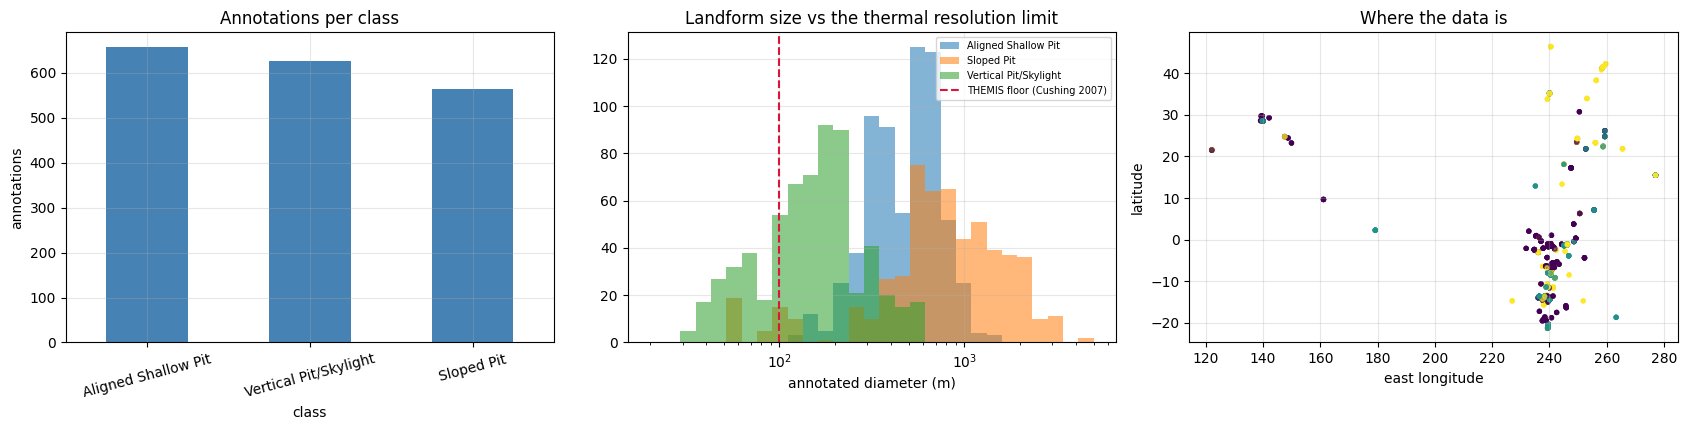

Geographic concentration (10 deg cells):
lon_bin  lat_bin
240      -10        356
230      -20        292
240      -20        207
230      -10        207
         -30        135

top 5 cells hold 65% of all annotations -- Tharsis (Arsia/Pavonis) and Cerberus/Elysium.

Landform size against the 100 m THEMIS floor:
  median diameter, all classes : 396 m (4.0 THEMIS px)
  median diameter, Type-1 only : 155 m (1.6 THEMIS px)
  below 100 m                  : 10% of all, 24% of Type-1


In [11]:
annotations["class"] = annotations["category_id"].map(CLASS_NAMES)

fig, axs = plt.subplots(1, 3, figsize=(17, 4.4))

annotations["class"].value_counts().plot.bar(ax=axs[0], rot=15, color="steelblue")
axs[0].set_title("Annotations per class")
axs[0].set_ylabel("annotations")

for name, group in annotations.groupby("class"):
    axs[1].hist(group["diameter_m"], bins=np.logspace(1.3, 3.7, 30),
                alpha=0.55, label=name)
axs[1].axvline(100, ls="--", c="crimson", lw=1.5,
               label="THEMIS floor (Cushing 2007)")
axs[1].set_xscale("log")
axs[1].set_xlabel("annotated diameter (m)")
axs[1].set_title("Landform size vs the thermal resolution limit")
axs[1].legend(fontsize=7)

scatter = axs[2].scatter(annotations["lon_east"], annotations["lat"],
                         c=annotations["category_id"], cmap="viridis",
                         s=8, alpha=0.6)
axs[2].set_xlabel("east longitude")
axs[2].set_ylabel("latitude")
axs[2].set_title("Where the data is")
for ax in axs:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

region = annotations.assign(
    lon_bin=(annotations.lon_east // 10 * 10).astype(int),
    lat_bin=(annotations.lat // 10 * 10).astype(int),
)
top = region.groupby(["lon_bin", "lat_bin"]).size().sort_values(ascending=False)
print("Geographic concentration (10 deg cells):")
print(top.head(5).to_string())
print(f"\ntop 5 cells hold {top.head(5).sum() / len(annotations) * 100:.0f}% of "
      "all annotations -- Tharsis (Arsia/Pavonis) and Cerberus/Elysium.")

print("\nLandform size against the 100 m THEMIS floor:")
print(f"  median diameter, all classes : {annotations.diameter_m.median():.0f} m "
      f"({annotations.diameter_m.median() / 100:.1f} THEMIS px)")
skylights = annotations[annotations.category_id == 0]
print(f"  median diameter, Type-1 only : {skylights.diameter_m.median():.0f} m "
      f"({skylights.diameter_m.median() / 100:.1f} THEMIS px)")
print(f"  below 100 m                  : "
      f"{(annotations.diameter_m < 100).mean() * 100:.0f}% of all, "
      f"{(skylights.diameter_m < 100).mean() * 100:.0f}% of Type-1")

### Limitations to carry into the paper

1. **Sample size is 318 landform groups / 127 product groups**, not 1846 images.
   Report group-level `n`, use `StratifiedGroupKFold`, quote fold-to-fold spread.
   At product level Type-4 appears in only 37 groups.
2. **Geography.** Two volcanic provinces, one planet. That is where Martian pits
   are, so it is defensible, but it does not support a claim of "diverse
   planetary terrains". A region hold-out -- train Tharsis, test Elysium -- would
   be a stronger result than a random split and costs nothing.
3. **Solar incidence angle is the next confound to check.** What separates these
   classes optically is shadow depth and whether a floor is visible, and that is
   a function of illumination; Nodjoumi says as much. `stretch_intensity` removes
   the brightness offset but not the shadow geometry. Pull incidence angle per
   product and run the statistics-only baseline against it. If incidence alone
   predicts the class, that is a finding, not a nuisance.
4. **Label noise.** Classes were assigned by qualitative morphological inspection
   without topographic profiles, by the DeepLandforms authors' own description.
   Type-1b / Type-2a / Type-4 confusion is expected and bounds achievable
   accuracy.
5. **Georeferencing.** Nodjoumi reports uncontrolled misalignment between MGC^3
   points and the HiRISE products, and advises co-registration to a common
   basemap. That bounds how precisely thermal windows can be placed, whatever
   the code does.
6. **The skylight class sits at the thermal resolution limit.** Median annotated
   diameter is 396 m, i.e. 4.0 THEMIS pixels -- but for Type-1, the class that
   matters, it is 155 m, i.e. 1.6 pixels, and 24% of Type-1 annotations fall
   below Cushing's stated ~100 m detectability floor outright.

## 7. Thermal coverage is not random

The thermal pipeline (`data/thermal/`) queries one window per **landform site**
-- the same grouping the training split uses, so a site and a CV group are the
same object. Not every site gets one: THEMIS revisits depend on orbit geometry,
so some landforms have three usable frames, some have one, some none.

That missingness is a limitation to report rather than a bug to fix, but it has
to be *measured*, because **it is not independent of the class.** THEMIS
coverage depends on where a site is, and where a site is correlates with what it
is. If a model is handed zero-padded thermal for missing sites, it can read the
padding pattern and gain accuracy with no thermal physics involved at all --
which would look exactly like "multimodal fusion helps".

The cell below quantifies it: a classifier given the coverage bookkeeping and
**not one Kelvin value** is asked to predict the class. Whatever it scores above
the majority class is the size of the trap.

**This was a serious problem, and fixing the retrieval largely solved it.**
On the first pass -- grid-snapped sites, and an id pattern that silently dropped
32% of the archive -- coverage was patchy and strongly class-dependent, and a
classifier given nothing but the frame count scored 60.5% on binary against a
54.0% majority. Six points of "multimodal gain" available for free, with no
thermal physics involved.

With the retrieval fixed, 302 of 314 sites carry a full three-frame sequence and
the picture changes:

| task | availability only | majority | lift |
|---|---|---|---|
| 3-class | 41.7% | 35.6% | **+6.1** |
| binary Type-1 vs rest | 64.8% | 66.1% | **-1.3** |

**On the headline binary task the leak is gone** -- coverage predicts the class
no better than guessing the majority. On 3-class it survives, and the
decomposition below shows why: no single coverage feature carries more than
about +1.5, but all of them together carry +6.1. Coverage is not describing the
landform, it is fingerprinting *where on Mars* the landform is, and that
correlates with class.

Two consequences, both already in place in the code:

* The thermal branch takes an explicit **availability mask channel** rather than
  bare zeros. It does not remove the leak -- the model can still read the mask --
  but it turns it into a named input that can be ablated and measured, and it
  separately fixes a real problem, since THEMIS writes 0 for no-data and a cold
  pixel would otherwise be indistinguishable from a missing one.
* `model/baselines.availability_features` keeps this as a permanent control. If
  a multimodal model beats optical-only by no more than this baseline beats the
  majority class, the gain is coverage bookkeeping, not physics.

In [12]:
from model.baselines import availability_features, evaluate_baseline

ANNOTATION_SITES = os.path.join(DATA, "thermal", "annotation_sites.csv")
MANIFEST = os.path.join(DATA, "thermal", "themis_data", "window_manifest.json")

availability = None
if os.path.exists(ANNOTATION_SITES):
    annotation_sites = pd.read_csv(ANNOTATION_SITES)
    availability = availability_features(annotation_sites, MANIFEST)

if availability is None:
    print("No thermal manifest matching the current landform sites.")
    print("Run data/thermal/thermal_data_collection.ipynb, then re-run this cell.")
    print()
    print("The numbers in the markdown above are from the superseded grid-based")
    print("run and stand as the order of magnitude to expect.")
else:
    coverage = annotations[["category_id"]].copy()
    coverage["class"] = coverage["category_id"].map(CLASS_NAMES)
    coverage["n_frames"] = availability["n_frames"].to_numpy()

    print("Frames per site, as a share of each class:")
    print(pd.crosstab(coverage["class"], coverage["n_frames"],
                      normalize="index").round(3).to_string())
    print()
    print("Mean frames per class:")
    print(coverage.groupby("class")["n_frames"].mean().round(2).to_string())

    from scipy.stats import kruskal

    per_class = [coverage.loc[coverage.category_id == c, "n_frames"]
                 for c in sorted(coverage.category_id.unique())]
    statistic, pvalue = kruskal(*per_class)
    print()
    print(f"Kruskal-Wallis across classes: H = {statistic:.1f}, p = {pvalue:.2g}")

Frames per site, as a share of each class:
n_frames                   0      1      2      3
class                                            
Aligned Shallow Pit    0.008  0.000  0.000  0.992
Sloped Pit             0.027  0.000  0.041  0.933
Vertical Pit/Skylight  0.000  0.032  0.040  0.928

Mean frames per class:
class
Aligned Shallow Pit      2.98
Sloped Pit               2.88
Vertical Pit/Skylight    2.90

Kruskal-Wallis across classes: H = 35.6, p = 1.8e-08


Class information carried by thermal coverage alone (%):


,availability only,majority,lift
task,,,
3-class,41.7,35.6,6.1
binary Type-1 vs rest,64.8,66.1,-1.3


The 'lift' column is how much a multimodal model must beat
optical-only by before the gain can be attributed to thermal physics.


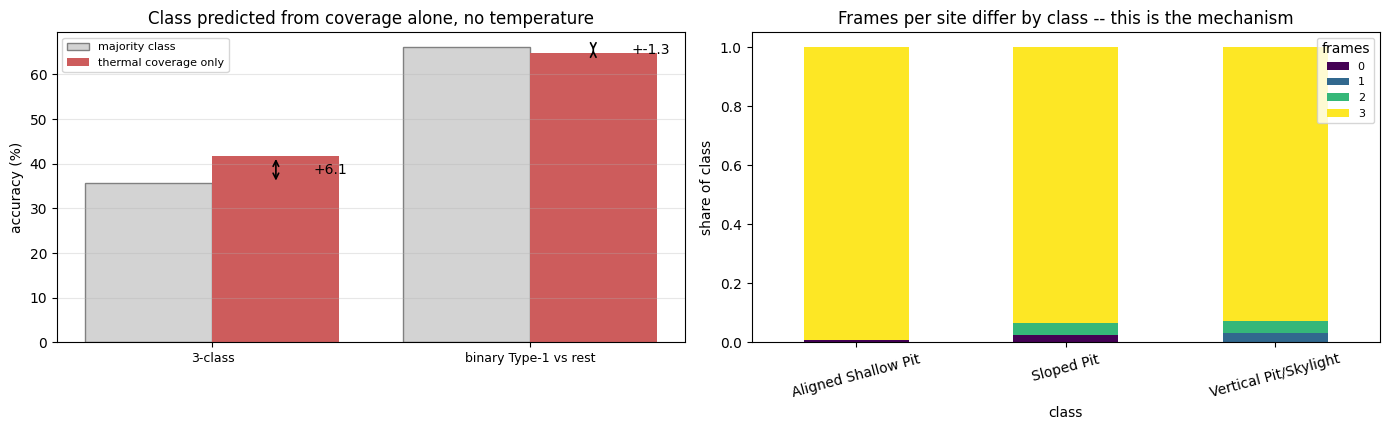

In [13]:
if availability is not None:
    # The control itself, scored exactly like every other baseline: same
    # group-aware folds, same estimator, no temperature anywhere in the input.
    groups = dataset.group_keys(level="product")

    rows = []
    for task_name, task_targets in (
        ("3-class", annotations["category_id"].to_numpy()),
        ("binary Type-1 vs rest",
         (annotations["category_id"] == 0).astype(int).to_numpy()),
    ):
        scored = evaluate_baseline(availability, task_targets, groups)
        floor = pd.Series(task_targets).value_counts(normalize=True).max()
        rows.append({
            "task": task_name,
            "availability only": scored["acc"].mean() * 100,
            "majority": floor * 100,
            "lift": (scored["acc"].mean() - floor) * 100,
        })

    leak = pd.DataFrame(rows).set_index("task").round(1)
    print("Class information carried by thermal coverage alone (%):")
    display(leak)
    print("The 'lift' column is how much a multimodal model must beat")
    print("optical-only by before the gain can be attributed to thermal physics.")

    fig, axs = plt.subplots(1, 2, figsize=(14, 4.4))

    positions = np.arange(len(leak))
    axs[0].bar(positions - 0.2, leak["majority"], 0.4,
               label="majority class", color="lightgrey", edgecolor="grey")
    axs[0].bar(positions + 0.2, leak["availability only"], 0.4,
               label="thermal coverage only", color="indianred")
    for x, (floor, scored) in enumerate(
        zip(leak["majority"], leak["availability only"])
    ):
        axs[0].annotate("", xy=(x + 0.2, scored), xytext=(x + 0.2, floor),
                        arrowprops=dict(arrowstyle="<->", color="black", lw=1.2))
        axs[0].text(x + 0.32, (scored + floor) / 2,
                    "+{:.1f}".format(scored - floor), va="center", fontsize=10)
    axs[0].set_xticks(positions)
    axs[0].set_xticklabels(leak.index, fontsize=9)
    axs[0].set_ylabel("accuracy (%)")
    axs[0].set_title("Class predicted from coverage alone, no temperature")
    axs[0].legend(fontsize=8)
    axs[0].grid(alpha=0.3, axis="y")

    shares = pd.crosstab(coverage["class"], coverage["n_frames"], normalize="index")
    shares.plot.bar(stacked=True, ax=axs[1], rot=15, colormap="viridis")
    axs[1].set_title("Frames per site differ by class -- this is the mechanism")
    axs[1].set_ylabel("share of class")
    axs[1].legend(title="frames", fontsize=8)

    plt.tight_layout()
    plt.show()

In [14]:
if availability is not None:
    # Which part of the coverage pattern carries the class? Each subset alone
    # against all of them together -- the gap between the two is the tell.
    subsets = {
        "frame count only": ["n_frames"],
        "counts": ["n_frames", "n_usable", "has_thermal"],
        "local solar time": ["lmst_min", "lmst_max", "lmst_span"],
        "pixel validity": ["valid_mean", "valid_min"],
        "all of them": list(availability.columns),
    }

    rows = []
    for task_name, task_targets in (
        ("3-class", annotations["category_id"].to_numpy()),
        ("binary Type-1 vs rest",
         (annotations["category_id"] == 0).astype(int).to_numpy()),
    ):
        floor = pd.Series(task_targets).value_counts(normalize=True).max() * 100
        for subset_name, columns in subsets.items():
            scored = evaluate_baseline(availability[columns], task_targets, groups)
            rows.append({
                "task": task_name,
                "features": subset_name,
                "accuracy": scored["acc"].mean() * 100,
                "lift over majority": scored["acc"].mean() * 100 - floor,
            })

    decomposition = (pd.DataFrame(rows)
                     .pivot(index="features", columns="task",
                            values="lift over majority")
                     .reindex(list(subsets))
                     .round(1))
    print("Lift over the majority class, by feature subset:")
    display(decomposition)
    print("No single subset carries much. Their combination carries more, which")
    print("is what a location fingerprint looks like: coverage is a proxy for")
    print("where the site is, and where correlates with what.")

Lift over the majority class, by feature subset:


task,3-class,binary Type-1 vs rest
features,,
frame count only,1.6,-0.7
counts,1.3,-1.8
local solar time,1.4,-4.6
pixel validity,1.7,-1.9
all of them,6.1,-1.3


No single subset carries much. Their combination carries more, which
is what a location fingerprint looks like: coverage is a proxy for
where the site is, and where correlates with what.


## 8. The superseded negative class

Kept because the measurement is a result in its own right, and because it is the
reason the task is framed the way it is.

### 8.1 Plain-terrain negatives (`plain_data_collection.py`, removed)

The first design added a fourth "plain terrain" class sampled from *other*
HiRISE products. Those negatives differed from the labelled landforms in
resolution, ground footprint, pixel dtype and region of Mars, so a classifier
could separate them without looking at morphology at all:

| features | plain vs rest |
|---|---|
| ground extent alone | 88.5% |
| all image statistics | 97.9% |

Normalising one artefact simply promoted the next: equalising resolution moved
the job to extent (66.3% -> 65.6%). **The lesson generalises past this project:
a negative class that does not share provenance with the positives measures the
data pipeline, not the model.**

### 8.2 Why the task changed

Pit-versus-plain is close to a shadow detector: measured pixel standard
deviation 26.1 for positives against 14.9 for negatives. Type-1 versus the rest
is the harder and more useful question, and it is not trivial -- Nodjoumi's own
Mask R-CNN got "poor results for all the classes" on this labelling and had to
merge classes down to a binary problem before the numbers moved.